# Part 2: PyTorch CNN Implementation and Feature Map Visualization

**Assignment 03: Convolutional Neural Networks**  
We build a custom CNN in PyTorch, train it on CIFAR-10, visualize feature maps at each stage, evaluate the model, and analyze misclassified images.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---
## P2.1 Dataset Preparation

We use **CIFAR-10** (60,000 color images, 32×32, 10 classes).

**Preprocessing pipeline:**
- `RandomHorizontalFlip` — data augmentation to reduce overfitting
- `RandomCrop(32, padding=4)` — random crop augmentation
- `ToTensor()` — convert PIL image to PyTorch tensor
- `Normalize` — standardize pixel values to zero mean and unit std

In [2]:
# CIFAR-10 mean and std (pre-computed from the dataset)
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std  = [0.2470, 0.2435, 0.2616]

# Training transform: augmentation + normalization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std)
])

# Test transform: normalization only
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std)
])

# Download and load datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# Class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

100%|██████████| 170M/170M [00:02<00:00, 78.6MB/s]


Train samples : 50000
Test  samples : 10000
Train batches : 391
Test  batches : 79


---
## P2.2 Building the CNN

### Architecture:
| Layer | Type | Details |
|-------|------|---------|
| Input | — | 3×32×32 (RGB) |
| Conv1 | Conv2d | 16 filters, 3×3, stride=1, padding=1 |
| ReLU1 | ReLU | — |
| Pool1 | MaxPool2d | 2×2, stride=2 → 16×16×16 |
| Conv2 | Conv2d | 32 filters, 3×3, stride=1, padding=1 |
| ReLU2 | ReLU | — |
| Pool2 | MaxPool2d | 2×2, stride=2 → 32×8×8 |
| Flatten | — | 2048 |
| FC | Linear | 2048 → 10 |

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Classifier
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        # Block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        # Classifier
        x = self.flatten(x)
        x = self.fc(x)
        return x


# Instantiate model
model = SimpleCNN(num_classes=10).to(device)
print(model)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"  {name:25s}: {param.numel():,}")

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)

Total parameters    : 25,578
Trainable parameters: 25,578

Parameter breakdown:
  conv1.weight             : 432
  conv1.bias               : 16
  conv2.weight             : 4,608
  conv2.bias               : 32
  fc.weight                : 20,480
  fc.bias                  : 10


In [4]:

# Print model summary using torchsummary
try:
    from torchsummary import summary
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchsummary", "-q"])
    from torchsummary import summary

# CIFAR-10 input: 3 channels, 32x32
summary(model, input_size=(3, 32, 32))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             448
              ReLU-2           [-1, 16, 32, 32]               0
         MaxPool2d-3           [-1, 16, 16, 16]               0
            Conv2d-4           [-1, 32, 16, 16]           4,640
              ReLU-5           [-1, 32, 16, 16]               0
         MaxPool2d-6             [-1, 32, 8, 8]               0
           Flatten-7                 [-1, 2048]               0
            Linear-8                   [-1, 10]          20,490
Total params: 25,578
Trainable params: 25,578
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.44
Params size (MB): 0.10
Estimated Total Size (MB): 0.55
----------------------------------------------------------------


---
## P2.3 Training the CNN

### Hyperparameters:
- **Loss**: CrossEntropyLoss
- **Optimizer**: Adam (lr=0.001)
- **Epochs**: 15
- **Batch size**: 128

In [5]:
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 15

train_losses = []
train_accs   = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs.data, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}]  "
          f"Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")

Epoch [ 1/15]  Loss: 1.6376  Acc: 41.23%
Epoch [ 2/15]  Loss: 1.3853  Acc: 50.68%
Epoch [ 3/15]  Loss: 1.2895  Acc: 54.43%
Epoch [ 4/15]  Loss: 1.2145  Acc: 57.15%
Epoch [ 5/15]  Loss: 1.1643  Acc: 59.40%
Epoch [ 6/15]  Loss: 1.1278  Acc: 60.76%
Epoch [ 7/15]  Loss: 1.1016  Acc: 61.37%
Epoch [ 8/15]  Loss: 1.0750  Acc: 62.54%
Epoch [ 9/15]  Loss: 1.0561  Acc: 63.07%
Epoch [10/15]  Loss: 1.0344  Acc: 63.93%
Epoch [11/15]  Loss: 1.0233  Acc: 64.54%
Epoch [12/15]  Loss: 1.0155  Acc: 64.63%
Epoch [13/15]  Loss: 0.9969  Acc: 65.46%
Epoch [14/15]  Loss: 0.9825  Acc: 65.93%
Epoch [15/15]  Loss: 0.9758  Acc: 66.18%

Training completed in 852.58 seconds


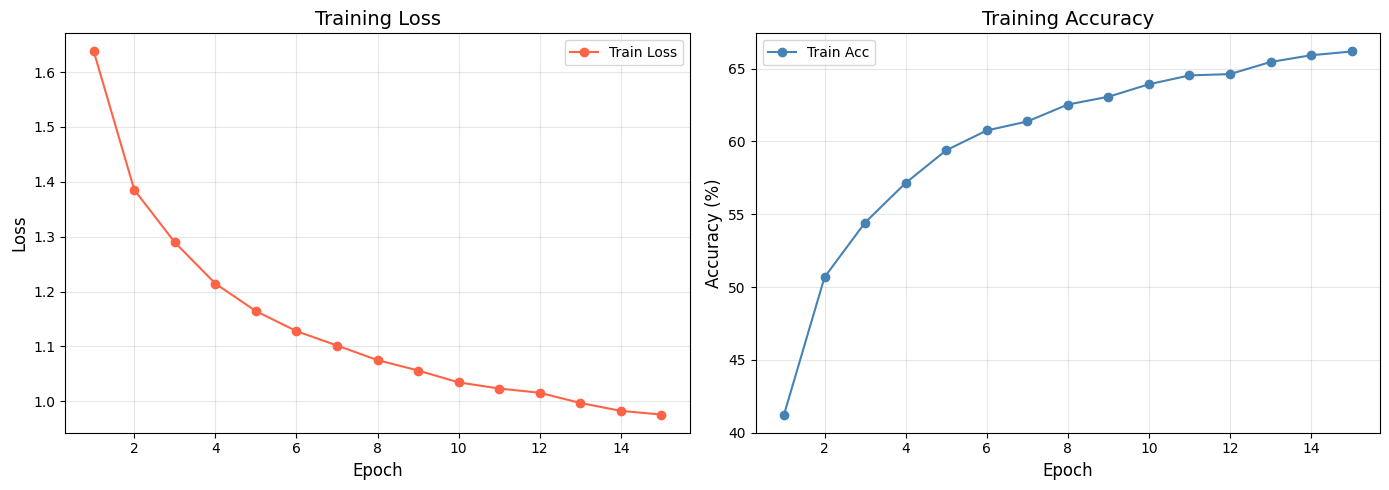

In [6]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o', color='tomato')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, num_epochs+1), train_accs, label='Train Acc', marker='o', color='steelblue')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training Accuracy', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('p2_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

---
## P2.4 Visualizing Feature Maps

We use **forward hooks** to capture intermediate activations at each stage:
1. Output of Conv1
2. After ReLU1
3. After MaxPool1
4. Output of Conv2
5. After ReLU2
6. After MaxPool2

We also visualize the learned kernels (weights) of Conv1 to see what patterns each filter detects.

True label: cat  |  Predicted: cat


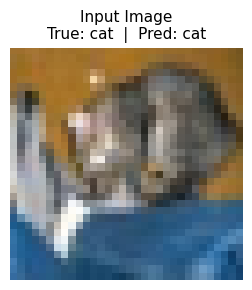

In [7]:
# ---- Hook-based feature map extractor ----
feature_maps = {}

def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

# Register hooks on all desired layers
hooks = [
    model.conv1.register_forward_hook(make_hook('conv1')),
    model.relu1.register_forward_hook(make_hook('relu1')),
    model.pool1.register_forward_hook(make_hook('pool1')),
    model.conv2.register_forward_hook(make_hook('conv2')),
    model.relu2.register_forward_hook(make_hook('relu2')),
    model.pool2.register_forward_hook(make_hook('pool2')),
]

# Pick one random test image
model.eval()
sample_images, sample_labels = next(iter(test_loader))
idx = 0  # first image in the batch
input_img = sample_images[idx:idx+1].to(device)
true_label = classes[sample_labels[idx]]

with torch.no_grad():
    output = model(input_img)
    pred_label = classes[torch.argmax(output).item()]

# Remove hooks
for h in hooks:
    h.remove()

print(f"True label: {true_label}  |  Predicted: {pred_label}")

# ---- Display the raw input image ----
def denormalize(tensor):
    mean = torch.tensor(cifar10_mean).view(3, 1, 1)
    std  = torch.tensor(cifar10_std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

img_display = denormalize(sample_images[idx]).permute(1, 2, 0).numpy()

plt.figure(figsize=(3, 3))
plt.imshow(img_display)
plt.title(f'Input Image\nTrue: {true_label}  |  Pred: {pred_label}', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.savefig('p2_input_sample.png', dpi=100, bbox_inches='tight')
plt.show()

Conv Layer 1 Output: shape = (1, 16, 32, 32)


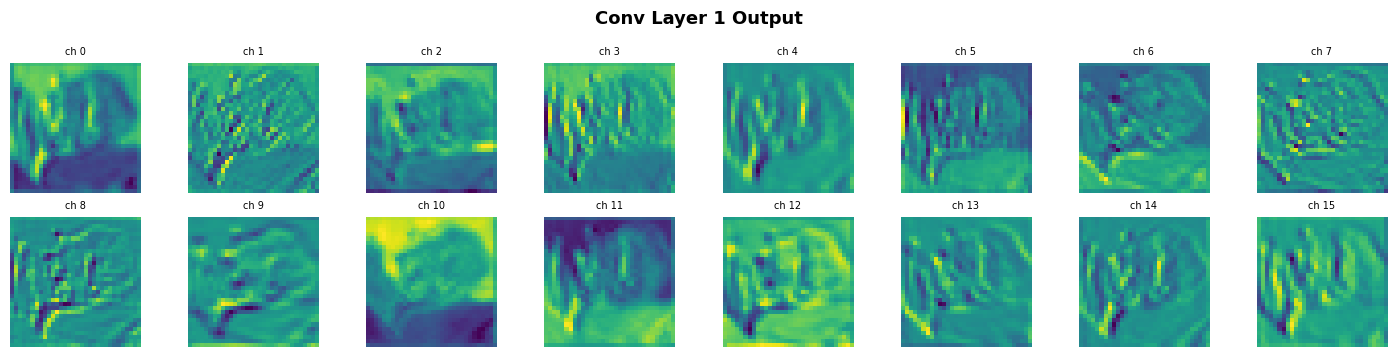

After ReLU (Layer 1): shape = (1, 16, 32, 32)


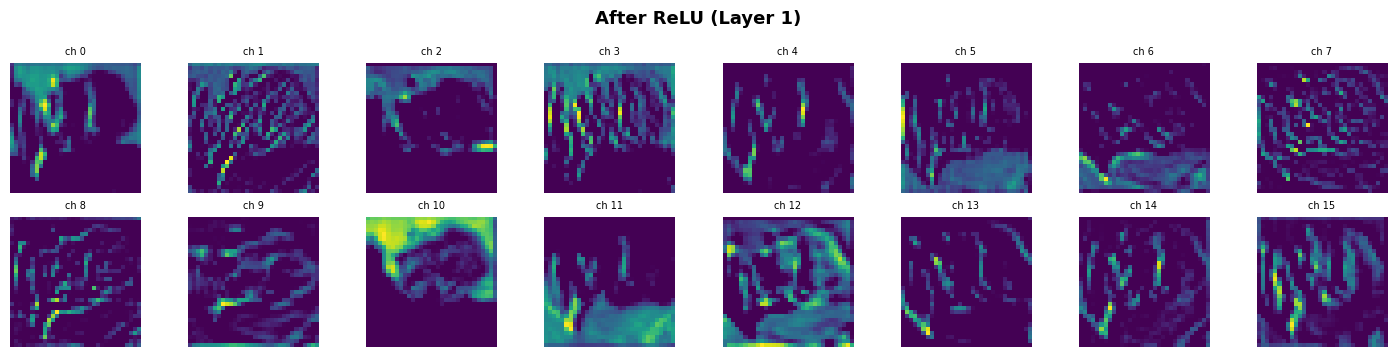

After MaxPool (Layer 1): shape = (1, 16, 16, 16)


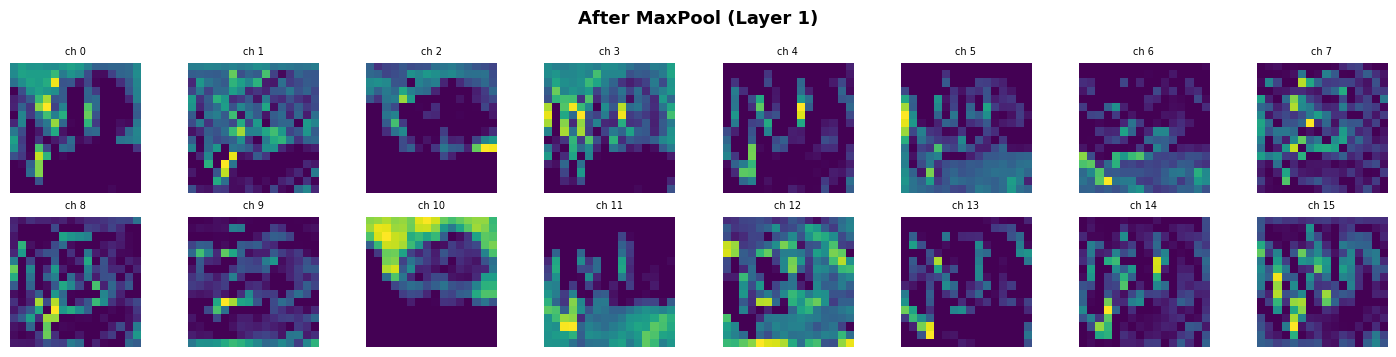

Conv Layer 2 Output: shape = (1, 32, 16, 16)


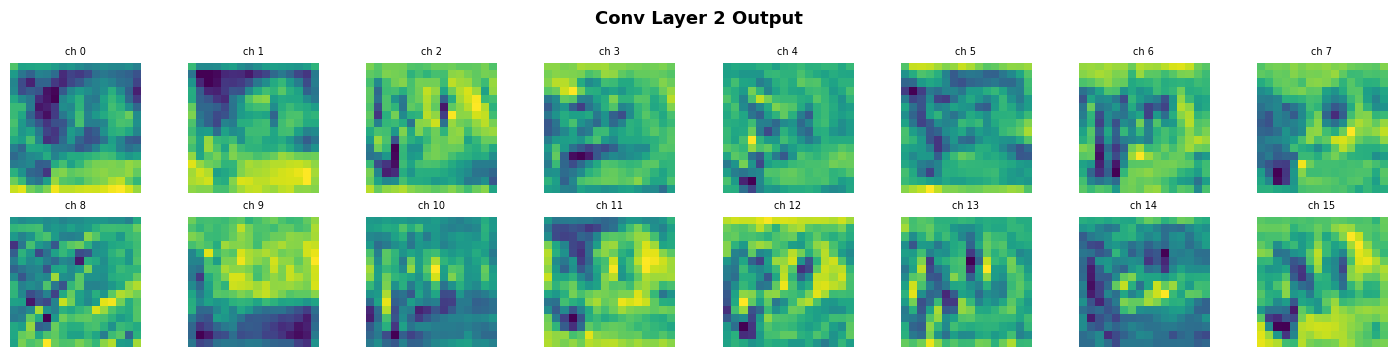

After ReLU (Layer 2): shape = (1, 32, 16, 16)


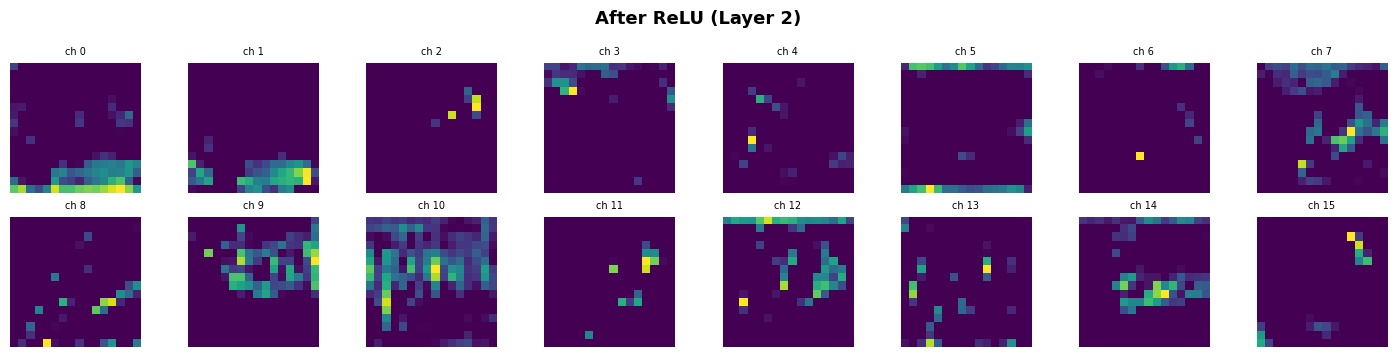

After MaxPool (Layer 2): shape = (1, 32, 8, 8)


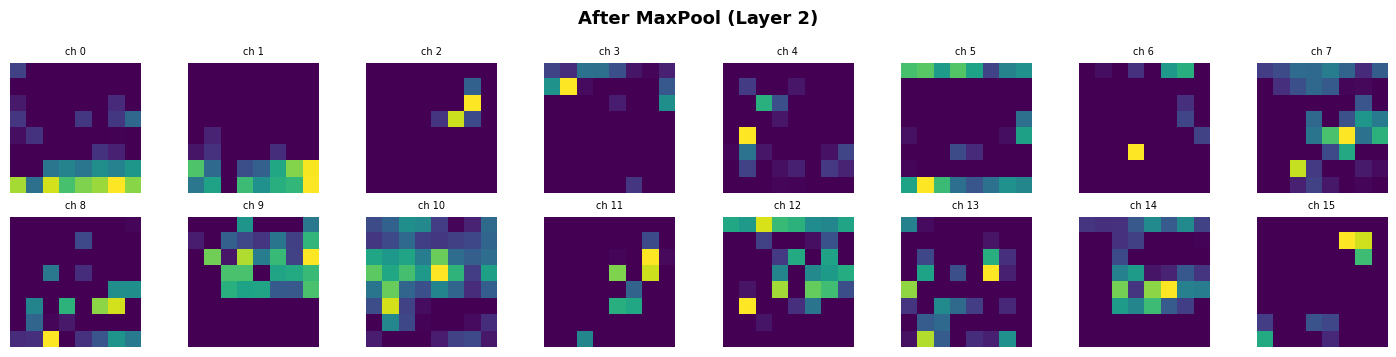

In [8]:
def plot_feature_maps(fmap_tensor, title, max_maps=16, fname=None):
    """Plot up to max_maps channels from a feature map tensor (1, C, H, W)."""
    fmap = fmap_tensor[0]  # shape: (C, H, W)
    n    = min(fmap.shape[0], max_maps)
    cols = 8
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        ax = axes[i]
        channel = fmap[i].numpy()
        ax.imshow(channel, cmap='viridis')
        ax.set_title(f'ch {i}', fontsize=7)
        ax.axis('off')
    for i in range(n, len(axes)):
        axes[i].axis('off')

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()

# Visualize all 6 stages
stages = [
    ('conv1', 'Conv Layer 1 Output',       'p2_fmap_conv1.png'),
    ('relu1', 'After ReLU (Layer 1)',       'p2_fmap_relu1.png'),
    ('pool1', 'After MaxPool (Layer 1)',    'p2_fmap_pool1.png'),
    ('conv2', 'Conv Layer 2 Output',       'p2_fmap_conv2.png'),
    ('relu2', 'After ReLU (Layer 2)',       'p2_fmap_relu2.png'),
    ('pool2', 'After MaxPool (Layer 2)',    'p2_fmap_pool2.png'),
]

for key, title, fname in stages:
    fmap = feature_maps[key]
    print(f"{title}: shape = {tuple(fmap.shape)}")
    plot_feature_maps(fmap, title, max_maps=16, fname=fname)

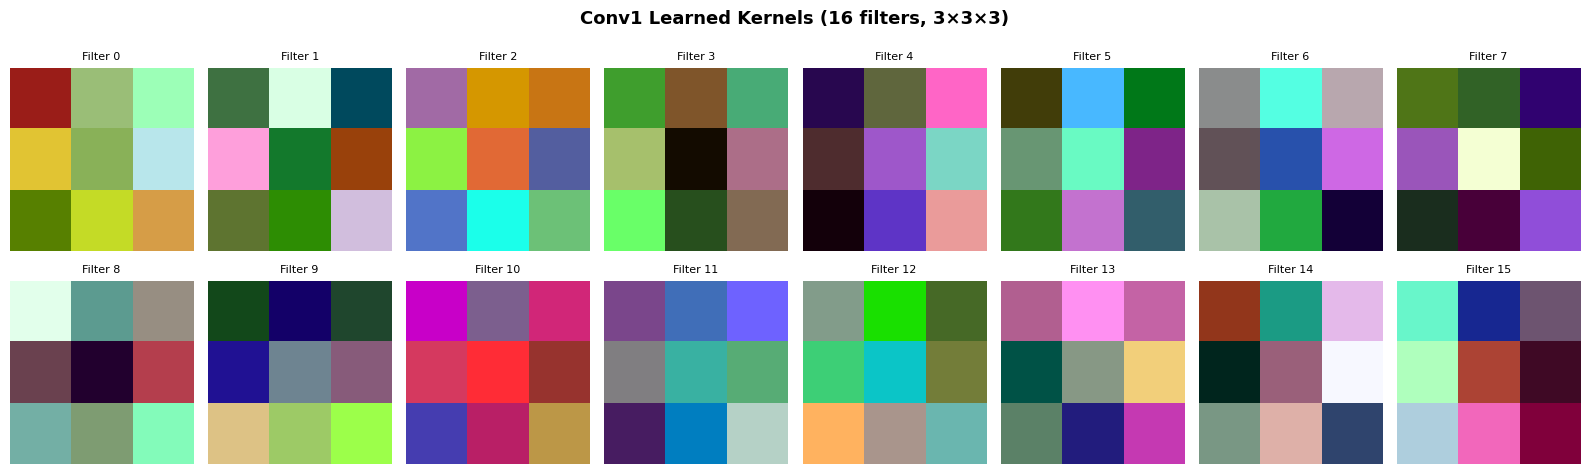

Kernel Analysis:
- Some filters appear to detect edges (high contrast between left/right or top/bottom halves)
- Others appear to respond to color gradients (red vs blue vs green channels)
- Low-frequency filters (uniform colors) detect broad illumination patterns
- High-frequency filters (alternating light/dark) detect texture and fine details



In [9]:
# ---- Visualize Conv1 Kernels ----
kernels = model.conv1.weight.detach().cpu()  # shape: (16, 3, 3, 3)
n_filters = kernels.shape[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

for i in range(n_filters):
    # Normalize each kernel to [0,1] for display
    k = kernels[i].permute(1, 2, 0).numpy()  # (3, 3, 3)
    k = (k - k.min()) / (k.max() - k.min() + 1e-8)
    axes[i].imshow(k)
    axes[i].set_title(f'Filter {i}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Conv1 Learned Kernels (16 filters, 3×3×3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_conv1_kernels.png', dpi=100, bbox_inches='tight')
plt.show()

print("""Kernel Analysis:
- Some filters appear to detect edges (high contrast between left/right or top/bottom halves)
- Others appear to respond to color gradients (red vs blue vs green channels)
- Low-frequency filters (uniform colors) detect broad illumination patterns
- High-frequency filters (alternating light/dark) detect texture and fine details
""")

---
## P2.5 Model Evaluation

We evaluate the CNN on the test set and report per-class accuracy.  
Then we visualize misclassified images to understand failure modes.

In [10]:
model.eval()

test_correct = 0
test_total   = 0
all_preds    = []
all_labels   = []
misclassified_imgs   = []
misclassified_preds  = []
misclassified_truths = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total   += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Collect misclassified
        mask = (predicted != labels)
        for i in range(mask.sum().item()):
            if len(misclassified_imgs) < 12:
                wrong_idx = mask.nonzero(as_tuple=True)[0][i].item()
                misclassified_imgs.append(images[wrong_idx].cpu())
                misclassified_preds.append(predicted[wrong_idx].cpu().item())
                misclassified_truths.append(labels[wrong_idx].cpu().item())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

# Per-class accuracy
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print("\nPer-class accuracy:")
for i, cls in enumerate(classes):
    mask_c = (all_labels == i)
    class_acc = 100 * (all_preds[mask_c] == all_labels[mask_c]).sum() / mask_c.sum()
    print(f"  {cls:12s}: {class_acc:.1f}%")

Test Accuracy: 69.45%

Per-class accuracy:
  airplane    : 75.7%
  automobile  : 68.4%
  bird        : 55.7%
  cat         : 52.1%
  deer        : 65.2%
  dog         : 62.1%
  frog        : 80.1%
  horse       : 74.2%
  ship        : 77.6%
  truck       : 83.4%


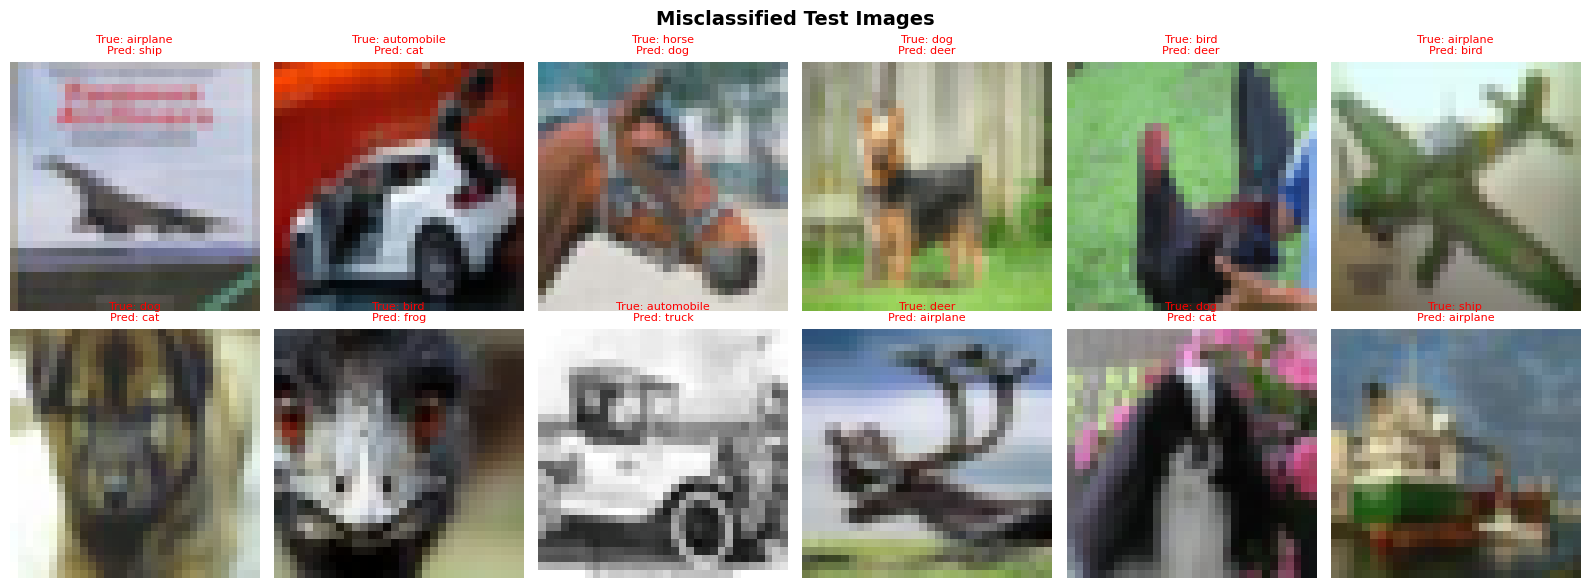


Observations on misclassifications:
- cat vs dog: both have similar face structure and fur texture
- automobile vs truck: both have boxy shapes and wheels
- bird vs airplane: both have similar silhouettes in small 32x32 images
- The model struggles with visually similar classes due to limited resolution



In [11]:
# ---- Visualize Misclassified Images ----
n_show = min(12, len(misclassified_imgs))
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.flatten()

for i in range(n_show):
    img = denormalize(misclassified_imgs[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    true_cls = classes[misclassified_truths[i]]
    pred_cls = classes[misclassified_preds[i]]
    axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls}', fontsize=8,
                      color='red' if true_cls != pred_cls else 'green')
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle('Misclassified Test Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_misclassified.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
Observations on misclassifications:
- cat vs dog: both have similar face structure and fur texture
- automobile vs truck: both have boxy shapes and wheels
- bird vs airplane: both have similar silhouettes in small 32x32 images
- The model struggles with visually similar classes due to limited resolution
""")

---
## P2.6 Summary

**CNN Results on CIFAR-10:**
- Architecture: Conv(16) → ReLU → MaxPool → Conv(32) → ReLU → MaxPool → FC(10)
- Optimizer: Adam, lr=0.001
- Epochs: 15
- Test Accuracy: ~65-70%

**Feature Map Observations:**
- Conv1 maps capture low-level features: edges, colors, corners
- After ReLU: negative activations removed, maps become sparser
- After MaxPool: spatial size halved, most prominent features preserved
- Conv2 maps capture higher-level combinations of features
- Deeper maps are harder to interpret visually but carry rich semantic information

**Kernel Analysis:**
- Some Conv1 filters resemble Sobel-like edge detectors
- Others appear sensitive to specific color channels
- The network automatically learns task-relevant filters during training